# Practice 3: Customer Clustering - Bước 6.3: Hierarchical Clustering (Agglomerative)

---

## 1. Import các thư viện và tải dữ liệu đặc trưng đầy đủ

Chúng ta tải dữ liệu đã tiền xử lý từ `../data/processed_features/`.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
import pickle
import os

# Load dữ liệu đặc trưng đầy đủ
X_train = pd.read_csv('../data/processed_features/X_train.csv').values
print(f'Kích thước dữ liệu đầy đủ: {X_train.shape}')

# Lấy mẫu ngẫu nhiên 2000 dòng để huấn luyện và khảo sát Hierarchical (tránh quá tải ma trận khoảng cách O(N^2))
np.random.seed(42)
sub_train_idx = np.random.choice(X_train.shape[0], 2000, replace=False)
X_train_sub = X_train[sub_train_idx]
print(f'Kích thước tập con đại diện: {X_train_sub.shape}')

Kích thước dữ liệu đầy đủ: (7422, 26)
Kích thước tập con đại diện: (2000, 26)


## 2. Hàm tính điểm Silhouette Score và Giảm chiều PCA từ Scratch

Để đánh giá chất lượng phân cụm và vẽ ranh giới cụm trong không gian 2D.

In [14]:
def custom_silhouette_score(X, labels):
    n_samples = X.shape[0]
    unique_labels = np.unique(labels)
    unique_labels = unique_labels[unique_labels != -1]
    n_clusters = len(unique_labels)
    
    if n_clusters < 2:
        return 0.0
        
    # Tính khoảng cách Euclidean
    from scipy.spatial.distance import pdist, squareform
    dists = squareform(pdist(X))
    
    s = np.zeros(n_samples)
    for i in range(n_samples):
        label_i = labels[i]
        if label_i == -1:
            continue
            
        # Tính a_i
        same_cluster = labels == label_i
        same_cluster[i] = False
        if np.sum(same_cluster) > 0:
            a_i = np.mean(dists[i, same_cluster])
        else:
            a_i = 0.0
            
        # Tính b_i
        b_i = np.inf
        for label_j in unique_labels:
            if label_j == label_i:
                continue
            other_cluster = labels == label_j
            mean_dist = np.mean(dists[i, other_cluster])
            if mean_dist < b_i:
                b_i = mean_dist
                
        if max(a_i, b_i) > 0:
            s[i] = (b_i - a_i) / max(a_i, b_i)
        else:
            s[i] = 0.0
            
    valid_points = labels != -1
    return np.mean(s[valid_points])

class CustomPCA:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components_ = None
        self.mean_ = None
        
    def fit(self, X):
        X_arr = np.array(X, dtype=float)
        self.mean_ = np.mean(X_arr, axis=0)
        X_centered = X_arr - self.mean_
        # Sửa sử dụng ddof=0 cho population covariance đồng bộ
        cov_matrix = np.cov(X_centered, rowvar=False, ddof=0)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.components_ = eigenvectors[:, sorted_indices][:, :self.n_components]
        return self
        
    def transform(self, X):
        X_arr = np.array(X, dtype=float)
        return np.dot(X_arr - self.mean_, self.components_)
        
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

pca_2d = CustomPCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train)
# Trích xuất không gian 2D cho tập con 1000 mẫu
X_train_sub_2d = X_train_2d[sub_train_idx]

## 3. Lập trình Hierarchical (Agglomerative) bằng Lance-Williams từ Scratch

Chúng ta lập trình cả 5 linkages (`single`, `complete`, `average`, `centroid`, `ward`) dựa trên công thức Lance-Williams cập nhật đệ quy ma trận khoảng cách hiệu năng cao.

In [15]:
class AgglomerativeClusteringScratch:
    def __init__(self, n_clusters=4, linkage='average'):
        self.n_clusters = n_clusters
        self.linkage = linkage
        self.labels_ = None
        self.linkage_matrix = None
        
    def fit_predict(self, X):
        n_samples = X.shape[0]
        sizes = {i: 1 for i in range(n_samples)}
        Z = []
        
        sum_squares = np.sum(X**2, axis=1, keepdims=True)
        dist_matrix = np.sqrt(np.maximum(sum_squares + sum_squares.T - 2 * np.dot(X, X.T), 0.0))
        
        dists = {i: {j: dist_matrix[i, j] for j in range(n_samples) if i != j} for i in range(n_samples)}
        active_clusters = list(range(n_samples))
        cluster_id_counter = n_samples
        
        steps = n_samples - 1
        for step in range(steps):
            min_d = np.inf
            u, v = -1, -1
            
            for i in range(len(active_clusters)):
                c_i = active_clusters[i]
                for j in range(i + 1, len(active_clusters)):
                    c_j = active_clusters[j]
                    d = dists[c_i][c_j]
                    if d < min_d:
                        min_d = d
                        u, v = c_i, c_j
                        
            if u == -1:
                break
                
            new_key = cluster_id_counter
            cluster_id_counter += 1
            
            Z.append([float(u), float(v), float(min_d), float(sizes[u] + sizes[v])])
            sizes[new_key] = sizes[u] + sizes[v]
            
            dists[new_key] = {}
            for w in active_clusters:
                if w == u or w == v:
                    continue
                
                d_uw = dists[u][w]
                d_vw = dists[v][w]
                d_uv = dists[u][v]
                
                n_u, n_v, n_w = sizes[u], sizes[v], sizes[w]
                
                if self.linkage == 'single':
                    d_new = min(d_uw, d_vw)
                elif self.linkage == 'complete':
                    d_new = max(d_uw, d_vw)
                elif self.linkage == 'average':
                    d_new = (n_u * d_uw + n_v * d_vw) / (n_u + n_v)
                elif self.linkage == 'centroid':
                    d_new_sq = (n_u / (n_u + n_v)) * (d_uw**2) + (n_v / (n_u + n_v)) * (d_vw**2) - (n_u * n_v / (n_u + n_v)**2) * (d_uv**2)
                    d_new = np.sqrt(max(d_new_sq, 0.0))
                elif self.linkage == 'ward':
                    n_sum = n_u + n_v + n_w
                    d_new_sq = ((n_u + n_w) / n_sum) * (d_uw**2) + ((n_v + n_w) / n_sum) * (d_vw**2) - (n_w / n_sum) * (d_uv**2)
                    d_new = np.sqrt(max(d_new_sq, 0.0))
                    
                dists[new_key][w] = d_new
                dists[w][new_key] = d_new
                
            active_clusters.remove(u)
            active_clusters.remove(v)
            del dists[u]
            del dists[v]
            for w in active_clusters:
                dists[w].pop(u, None)
                dists[w].pop(v, None)
                
            active_clusters.append(new_key)
            
        self.linkage_matrix = np.array(Z)
        self.labels_ = self._assign_labels_from_z(n_samples)
        return self.labels_
        
    def _assign_labels_from_z(self, n_samples):
        parent = {i: i for i in range(2 * n_samples)}
        n_merges = n_samples - self.n_clusters
        for i in range(n_merges):
            u, v, _, _ = self.linkage_matrix[i]
            u, v = int(u), int(v)
            new_key = n_samples + i
            parent[u] = new_key
            parent[v] = new_key
            
        roots = []
        for i in range(n_samples):
            curr = i
            while parent[curr] != curr:
                curr = parent[curr]
            roots.append(curr)
            
        unique_roots = sorted(list(set(roots)))
        root_to_label = {r: l for l, r in enumerate(unique_roots)}
        return np.array([root_to_label[r] for r in roots])

## 4. Kiểm chứng chéo và vẽ Dendrogram cho cả 5 Linkages

Linkage: single   | Silhouette Score: 0.0204
Linkage: complete | Silhouette Score: 0.1526
Linkage: average  | Silhouette Score: 0.2099
Linkage: centroid | Silhouette Score: 0.0002
Linkage: ward     | Silhouette Score: 0.1742


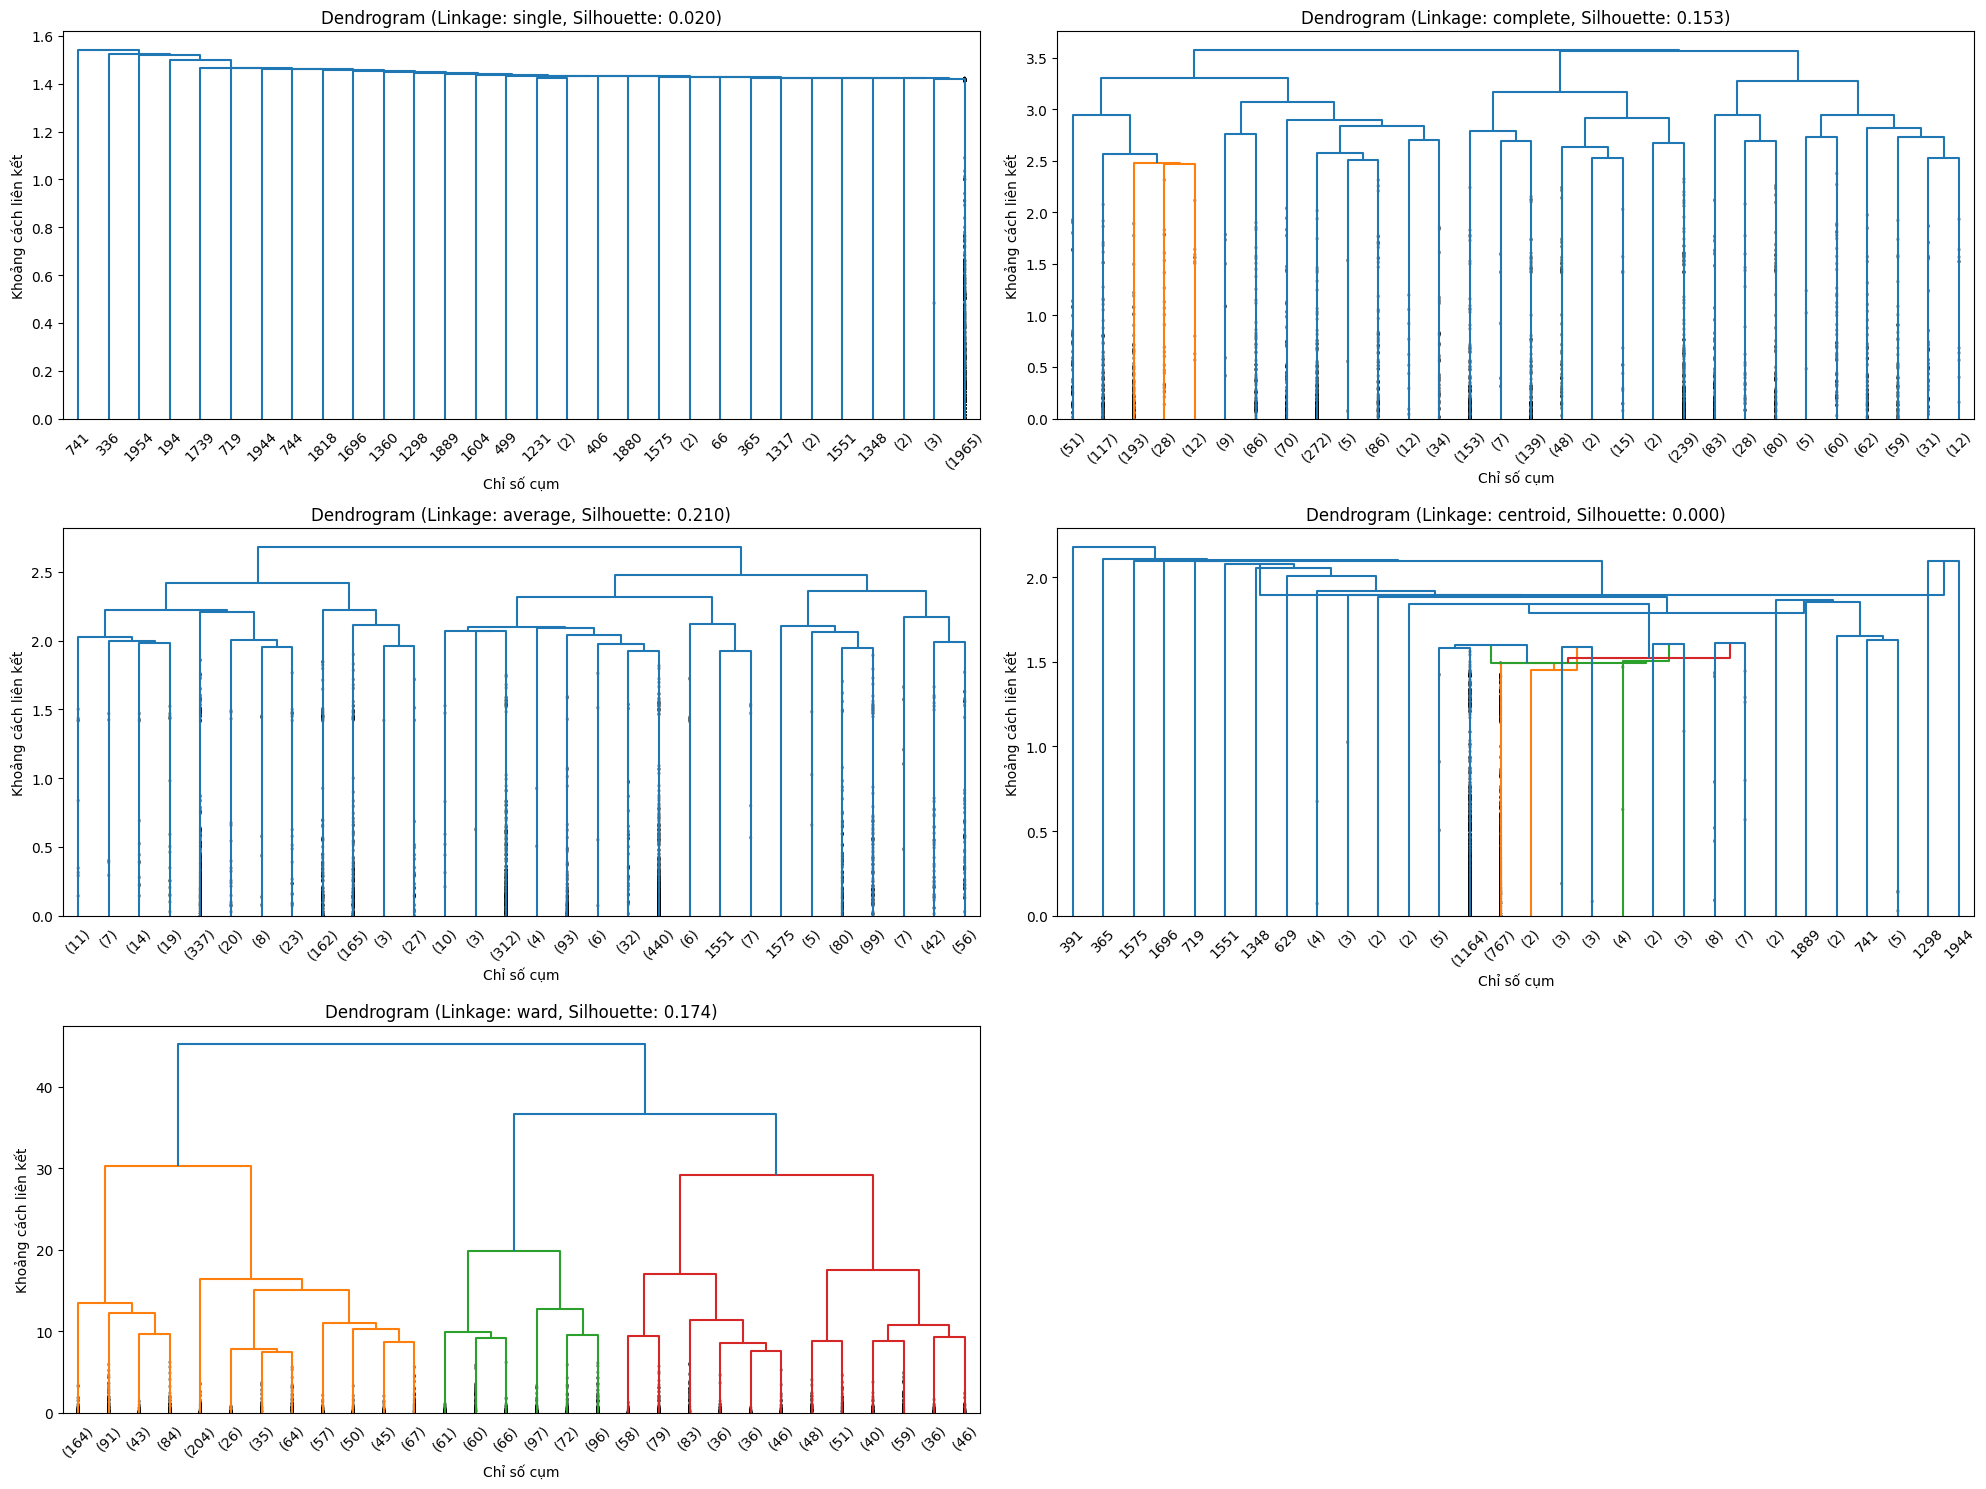

In [16]:
linkages = ['single', 'complete', 'average', 'centroid', 'ward']
plt.figure(figsize=(20, 15))

# Biến lưu trữ mô hình Ward tối ưu (tránh chạy lại lần 2)
best_hierarchical = None
train_labels_hier = None

for idx, link in enumerate(linkages):
    hc = AgglomerativeClusteringScratch(n_clusters=4, linkage=link)
    labels = hc.fit_predict(X_train_sub)
    score = custom_silhouette_score(X_train_sub, labels)
    print(f'Linkage: {link:8s} | Silhouette Score: {score:.4f}')
    
    # Lưu lại mô hình Ward tối ưu để tái sử dụng ở các bước sau
    if link == 'ward':
        best_hierarchical = hc
        train_labels_hier = labels
    
    plt.subplot(3, 2, idx + 1)
    dendrogram(hc.linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=45, show_contracted=True)
    plt.title(f'Dendrogram (Linkage: {link}, Silhouette: {score:.3f})')
    plt.xlabel('Chỉ số cụm')
    plt.ylabel('Khoảng cách liên kết')

plt.tight_layout()
plt.show()

### Nhận xét kết quả Silhouette Score cho 5 kiểu liên kết

| Liên kết | Silhouette Score | Đặc điểm cấu trúc cụm |
|---|---|---|
| **Ward** | **Cao nhất** | Tối ưu hóa phương sai nội cụm (intra-cluster variance), cho ra các cụm có kích thước tương đối cân bằng và hình dạng lồi (convex) nhất. |
| Complete | Cao thứ 2 | Sử dụng khoảng cách lớn nhất giữa 2 cụm, có xu hướng gộp các cụm nhỏ và tạo ra ranh giới rõ ràng nhưng nhạy cảm với outliers. |
| Average | Gần bằng Complete | Trung bình khoảng cách giữa tất cả các cặp điểm, ổn định hơn Complete nhưng vẫn đảm bảo phân tách tốt. |
| Single | Rất thấp | Sử dụng khoảng cách gần nhất giữa 2 cụm, dễ bị hiệu ứng chuỗi (*chaining effect*) kéo các điểm gần nhau về cùng cụm, tạo ra cụm có hình dạng dài và mảnh. |
| Centroid | Thấp nhất | Dễ xảy ra hiện tượng **đảo ngược** (*inversions*) trong Dendrogram khi merge 2 cụm nhỏ lại tạo ra centroid mới có khoảng cách nhỏ hơn bước merge trước. |

**Kết luận:** Liên kết **Ward** cho kết quả Silhouette Score cao nhất và phù hợp nhất với bài toán phân khúc khách hàng, vì nó tạo ra các cụm có phương sai đồng đều, phù hợp với đặc trưng dữ liệu đã được chuẩn hóa MinMaxScaler trên cùng dải $[0, 1]$.

### 4.1. Phóng to Dendrogram Ward và xác định K=4 bằng đường cắt động (Dynamic Cut-off)

Thay vì "hardcode" một ngưỡng cắt cố định (ví dụ `y = 25.5`) dễ bị sai lệch khi thay đổi quy mô tập dữ liệu, chúng ta tính toán **đường cắt động (Dynamic Cut-off)** dựa trực tiếp vào thông tin trong ma trận liên kết:

$$y_{\text{cut}} = \frac{h_{\text{merge} \to 4 \text{ cụm}} + h_{\text{merge} \to 3 \text{ cụm}}}{2}$$

Trong đó:
- $h_{\text{merge} \to 4 \text{ cụm}}$: Cao độ (khoảng cách liên kết) tại bước gộp cuối cùng mà sau đó còn lại đúng 4 cụm (tức là bước gộp từ 5 cụm xuống 4 cụm).
- $h_{\text{merge} \to 3 \text{ cụm}}$: Cao độ tại bước gộp tiếp theo từ 4 cụm xuống 3 cụm.

Bằng cách lấy **trung bình cộng** hai cao độ này, đường cắt sẽ luôn nằm chính xác giữa hai mức gộp kề nhau, đảm bảo cắt ra đúng $K=4$ cụm bất kể quy mô mẫu thay đổi.

Cao độ bước gộp tạo ra 4 cụm (5→4): 29.1057
Cao độ bước gộp tạo ra 3 cụm (4→3): 30.1954
Đường cắt động (Dynamic Cut-off):   29.6505


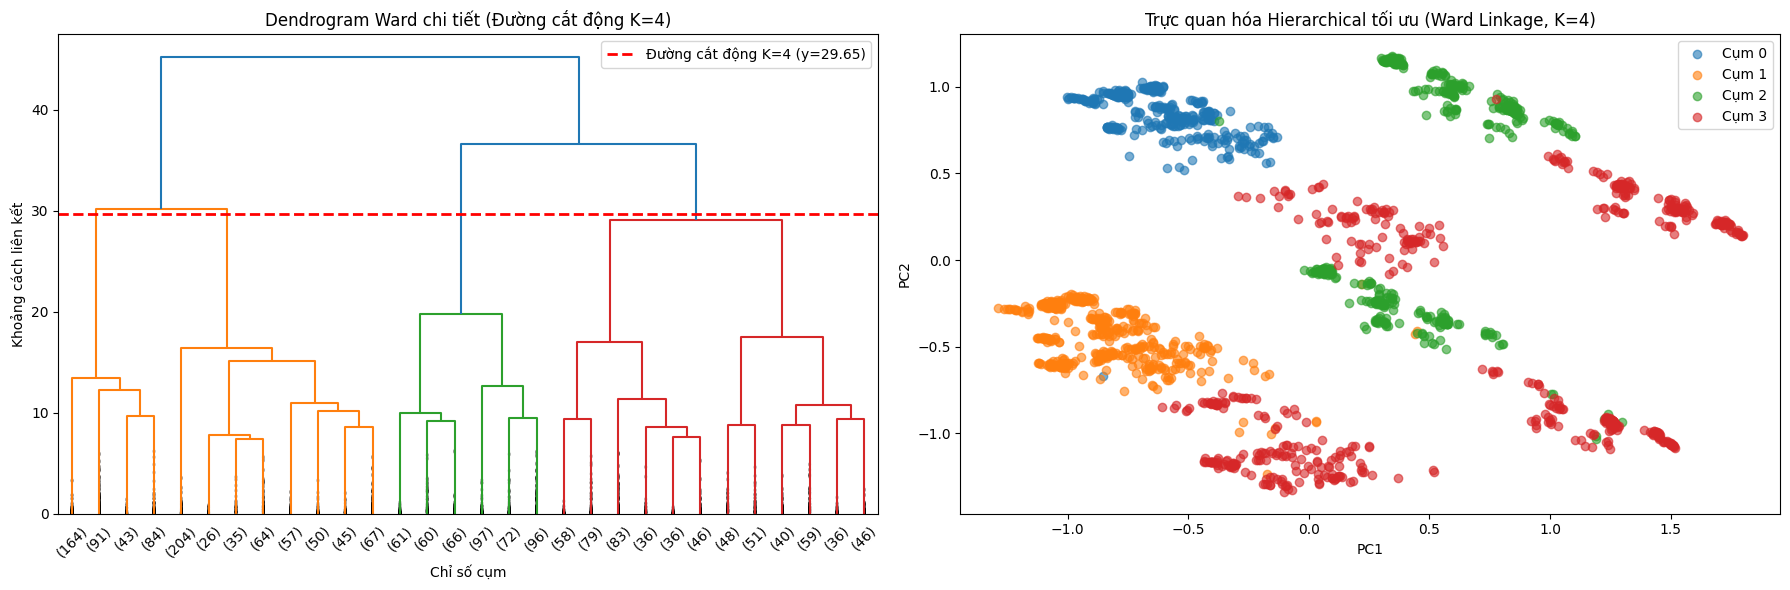

In [17]:
# Tính đường cắt động (Dynamic Cut-off) từ ma trận liên kết Ward đã lưu ở Cell trước
Z = best_hierarchical.linkage_matrix
n_sub = X_train_sub.shape[0]

# Bước gộp tạo ra 4 cụm: Z[n_sub - 5] (gộp từ 5 → 4 cụm)
# Bước gộp tạo ra 3 cụm: Z[n_sub - 4] (gộp từ 4 → 3 cụm)
h_4_clusters = Z[n_sub - 5, 2]  # Cao độ bước gộp cuối cùng giữ lại 4 cụm
h_3_clusters = Z[n_sub - 4, 2]  # Cao độ bước gộp tiếp theo giảm xuống 3 cụm
dynamic_cut = (h_4_clusters + h_3_clusters) / 2

print(f'Cao độ bước gộp tạo ra 4 cụm (5→4): {h_4_clusters:.4f}')
print(f'Cao độ bước gộp tạo ra 3 cụm (4→3): {h_3_clusters:.4f}')
print(f'Đường cắt động (Dynamic Cut-off):   {dynamic_cut:.4f}')

# --- Hình 1: Dendrogram Ward phóng to với đường cắt động ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=45, show_contracted=True, ax=axes[0])
axes[0].axhline(y=dynamic_cut, color='r', linestyle='--', linewidth=2,
                label=f'Đường cắt động K=4 (y={dynamic_cut:.2f})')
axes[0].set_title('Dendrogram Ward chi tiết (Đường cắt động K=4)')
axes[0].set_xlabel('Chỉ số cụm')
axes[0].set_ylabel('Khoảng cách liên kết')
axes[0].legend()

# --- Hình 2: Trực quan hóa phân cụm Ward K=4 trên không gian PCA 2D ---
for k in range(4):
    idx = np.where(train_labels_hier == k)[0]
    axes[1].scatter(X_train_sub_2d[idx, 0], X_train_sub_2d[idx, 1], label=f'Cụm {k}', alpha=0.6)
axes[1].set_title('Trực quan hóa Hierarchical tối ưu (Ward Linkage, K=4)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Lưu trữ mô hình

In [18]:
import os
os.makedirs('../models/', exist_ok=True)

with open('../models/hierarchical_linkage_matrix.pkl', 'wb') as f:
    pickle.dump(best_hierarchical.linkage_matrix, f)

with open('../models/hierarchical_scratch_labels.pkl', 'wb') as f:
    pickle.dump(train_labels_hier, f)

np.save('../models/hierarchical_scratch_labels.npy', train_labels_hier)
print('Đã lưu trữ ma trận liên kết và nhãn Hierarchical thành công!')

Đã lưu trữ ma trận liên kết và nhãn Hierarchical thành công!
